# Notebook 3 — Clustering & Dimensionality Reduction

**Goal:** Find natural groups ("clusters") in the data. Are there distinct game states like "close combat" vs "long-range circling"? Do different robots occupy different regions of feature space?

## Key Concepts

### Standardization (z-score)
Before clustering, we need to put all features on the same scale. Distance ranges from 0–800 pixels, but velocity ranges from −8 to +8. Without scaling, distance would dominate everything.

**Z-score formula:** $z = \frac{x - \text{mean}}{\text{std}}$

After standardization, every feature has mean = 0 and std = 1. Interpretation: z = +2 means "2 standard deviations above average" = unusually high.

### PCA (Principal Component Analysis)
We have ~24 features (dimensions). You can't draw a 24-dimensional picture. PCA finds the 2 directions that capture the most "spread" (variance) in the data, so we can make a 2D scatter plot.

**Analogy:** Imagine a cloud of points in 3D space. PCA finds the direction you should look at the cloud from to see the most spread. Like flattening a rugby ball — you want to look from the side, not the end.

### K-Means Clustering
Groups data points into K clusters by:
1. Pick K random center points
2. Assign each data point to its nearest center
3. Move each center to the average of its assigned points
4. Repeat steps 2–3 until centers stop moving

### Elbow Method
Run K-Means for K = 2, 3, 4, ..., 10. Plot the total "error" (sum of distances from each point to its center, called **inertia**). The plot usually bends — the "elbow" is the best K, because adding more clusters beyond that barely helps.

In [1]:
# --- Setup & Load ---
# Stratified per-robot sample to keep RAM bounded (full dataset is ~20 GB).
import sys; sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from _loader import build_robot_index, load_stratified, numeric_feature_cols

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

selection = build_robot_index(max_robots=50, battles_per_robot=3, seed=42)
ticks = load_stratified('ticks.csv', selection, row_frac=0.20)
waves = load_stratified('waves.csv', selection)

feature_cols = numeric_feature_cols(ticks)
print(f"Loaded {len(ticks):,} ticks, {len(feature_cols)} features")


Indexed 3888 ticks.csv files across 50 distinct robots from 1 root(s).
Selected 50 robots × ~3 battles = 150 (battle, robot) pairs to load.


Loaded 150 ticks.csv files → 1,003,073 rows × 65 cols, 50 robots (~354.6 MB)


Loaded 150 waves.csv files → 281,447 rows × 10 cols, 50 robots (~43.5 MB)
Loaded 1,003,073 ticks, 60 features


## Step 1 — Standardize and Handle Missing Values

We drop NaN rows for clustering (can't compute distance to a missing value). Then we standardize all features to z-scores.

Rows with complete data (scan ticks, no NaN): 803,817 out of 1,003,073
That's 80.1% of all ticks


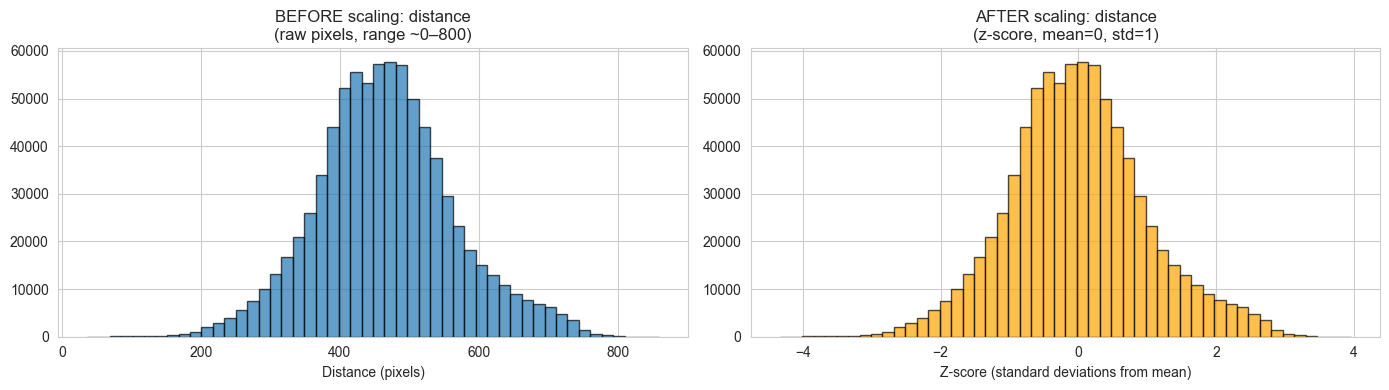

In [2]:
# --- Prepare data for clustering ---
# Keep only scan ticks (where we have opponent data) and drop remaining NaN
scan_ticks = ticks[ticks['scan_available'] == 1].copy()
features_df = scan_ticks[feature_cols].dropna()
robot_names = scan_ticks.loc[features_df.index, 'robot_name']

print(f"Rows with complete data (scan ticks, no NaN): {len(features_df):,} out of {len(ticks):,}")
print(f"That's {len(features_df)/len(ticks)*100:.1f}% of all ticks")

# Standardize: z = (x - mean) / std
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_df)

# Show before vs after for one feature
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(features_df['distance'], bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title("BEFORE scaling: distance\n(raw pixels, range ~0–800)")
axes[0].set_xlabel("Distance (pixels)")

dist_idx = feature_cols.index('distance')
axes[1].hist(X_scaled[:, dist_idx], bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title("AFTER scaling: distance\n(z-score, mean=0, std=1)")
axes[1].set_xlabel("Z-score (standard deviations from mean)")

plt.tight_layout()
plt.show()

## Step 2 — PCA: Reduce to 2D for Visualization

We project our ~24 features onto 2 "principal components." The **scree plot** shows how much information each component captures. If the first 2 components capture >50% of the variance, our 2D picture is a reasonable representation.

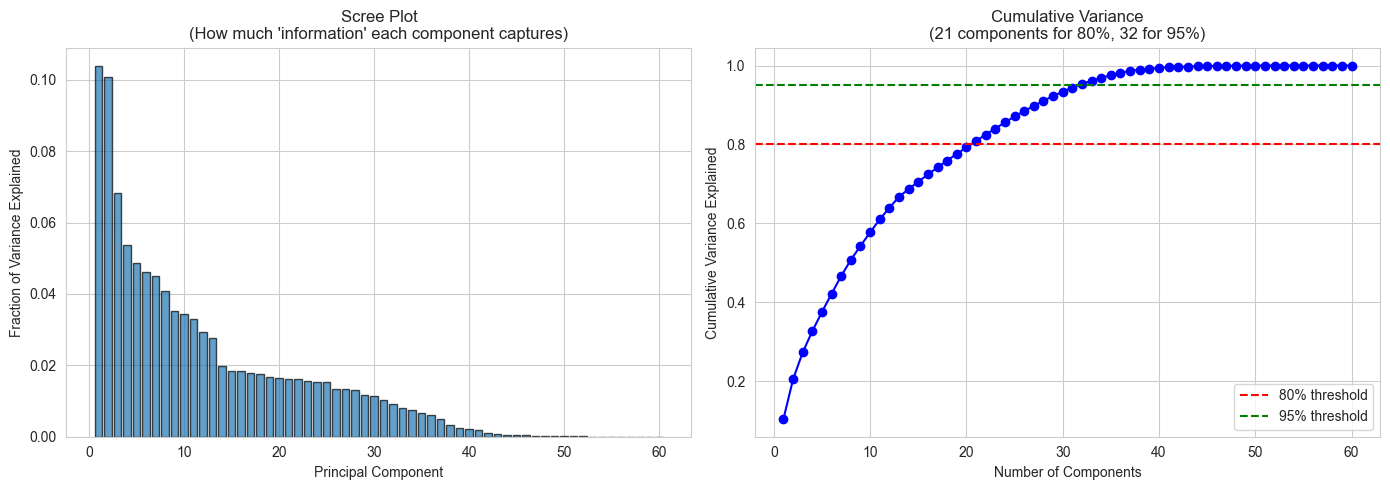


First 2 components explain 20.5% of total variance


In [3]:
# --- PCA ---
pca_full = PCA()
pca_full.fit(X_scaled)

# Scree plot: how much variance does each component explain?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, alpha=0.7, edgecolor='black')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Fraction of Variance Explained")
axes[0].set_title("Scree Plot\n(How much 'information' each component captures)")

# Cumulative explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumvar) + 1), cumvar, 'bo-')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
n_80 = np.argmax(cumvar >= 0.80) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].set_title(f"Cumulative Variance\n({n_80} components for 80%, {n_95} for 95%)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Project to 2D
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)
print(f"\nFirst 2 components explain {pca_2d.explained_variance_ratio_.sum()*100:.1f}% of total variance")

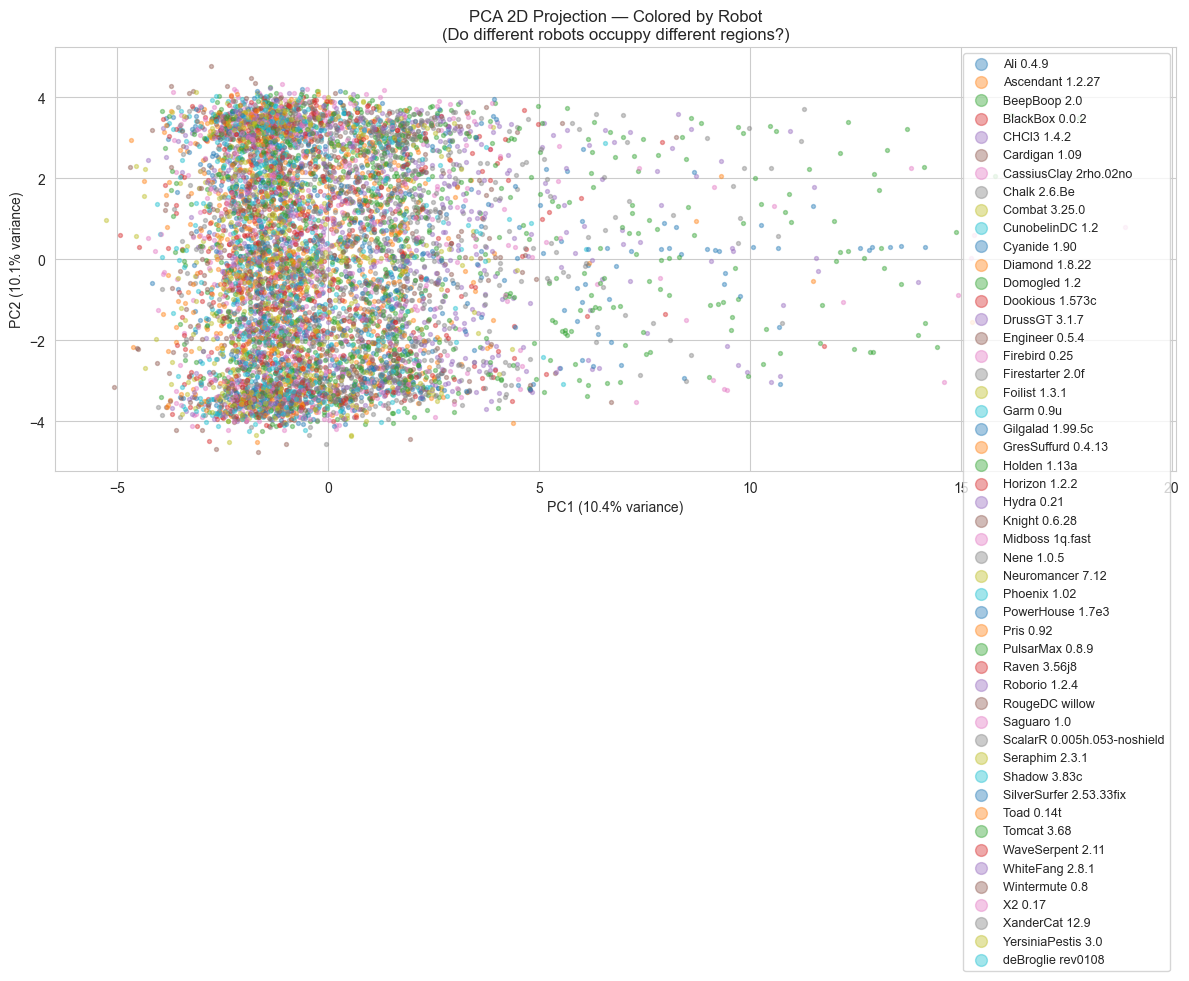


Top features contributing to each principal component:

PC1 (largest loadings):
opponent_bullet_speed      0.295388
our_bullet_speed           0.289577
mea_for_opponent_bullet    0.289062
mea_for_our_bullet         0.284239
opponent_wave_eta          0.265272

PC2 (largest loadings):
opponent_lateral_velocity           0.403394
linear_target_offset                0.402213
opponent_angular_velocity           0.398009
circular_target_offset              0.387109
opponent_avg_lateral_velocity_10    0.370074


In [4]:
# --- PCA colored by robot name ---
fig, ax = plt.subplots(figsize=(12, 8))

# Sample for readability
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), min(8000, len(X_pca)), replace=False)

for robot in sorted(robot_names.unique()):
    mask = robot_names.iloc[sample_idx].values == robot
    ax.scatter(X_pca[sample_idx[mask], 0], X_pca[sample_idx[mask], 1], 
               label=robot, alpha=0.4, s=8)

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA 2D Projection — Colored by Robot\n(Do different robots occuppy different regions?)")
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.show()

# Show what each PC is made of (feature loadings)
loadings = pd.DataFrame(pca_2d.components_.T, index=feature_cols, columns=['PC1', 'PC2'])
print("\nTop features contributing to each principal component:")
print("\nPC1 (largest loadings):")
print(loadings['PC1'].abs().nlargest(5).to_string())
print("\nPC2 (largest loadings):")
print(loadings['PC2'].abs().nlargest(5).to_string())

## Step 3 — K-Means Clustering

### Elbow Method + Silhouette Score

We try K = 2 through 10 and measure:
- **Inertia** = total distance of points to their cluster centers (lower = tighter clusters)
- **Silhouette score** = how well-separated clusters are (ranges −1 to +1, higher = better)

The "elbow" in the inertia plot = best trade-off between number of clusters and cluster quality.

K=2: inertia=1,063,983, silhouette=0.086


K=3: inertia=1,002,067, silhouette=0.070


K=4: inertia=948,438, silhouette=0.084


K=5: inertia=918,454, silhouette=0.066


K=6: inertia=880,370, silhouette=0.067


K=7: inertia=850,224, silhouette=0.070


K=8: inertia=831,966, silhouette=0.075


K=9: inertia=809,493, silhouette=0.077


K=10: inertia=791,547, silhouette=0.076


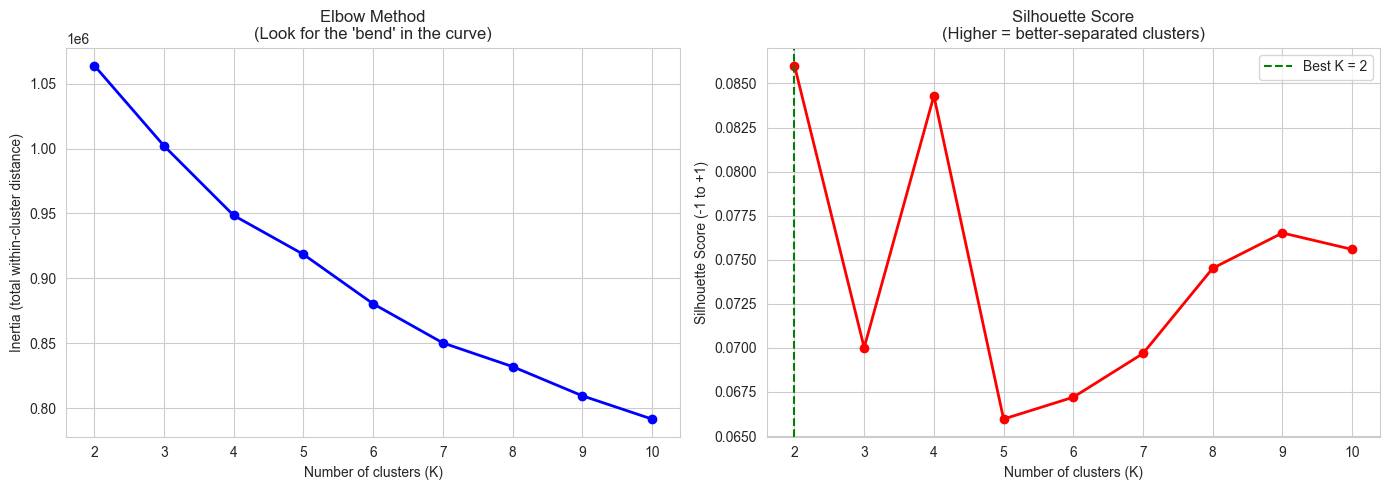


Best K by silhouette score: 2


In [5]:
# --- Elbow method ---
# Use a sample for speed (full dataset is ~200K rows)
np.random.seed(42)
sample_size = min(20000, len(X_scaled))
sample_idx_km = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx_km]

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=min(5000, sample_size))
    silhouettes.append(sil)
    print(f"K={k}: inertia={km.inertia_:,.0f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia (total within-cluster distance)")
axes[0].set_title("Elbow Method\n(Look for the 'bend' in the curve)")

axes[1].plot(list(K_range), silhouettes, 'ro-', linewidth=2)
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score (-1 to +1)")
axes[1].set_title("Silhouette Score\n(Higher = better-separated clusters)")

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Best K = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nBest K by silhouette score: {best_k}")

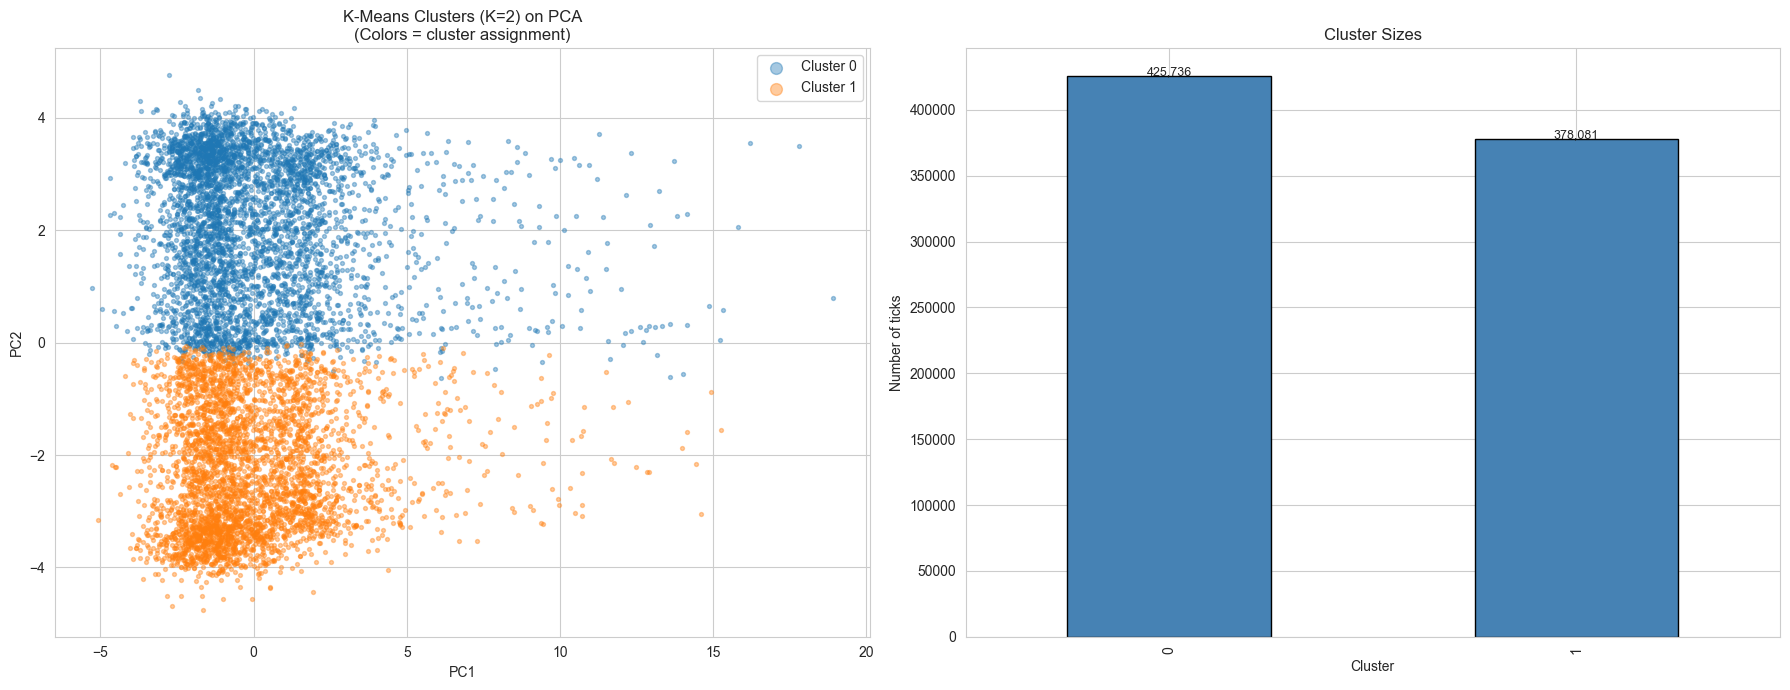

In [6]:
# --- Fit best K and visualize clusters on PCA projection ---
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_best.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA view colored by cluster
X_pca_sample = X_pca[sample_idx]
labels_sample = cluster_labels[sample_idx]

for c in range(best_k):
    mask = labels_sample == c
    axes[0].scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
                    label=f'Cluster {c}', alpha=0.4, s=8)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title(f"K-Means Clusters (K={best_k}) on PCA\n(Colors = cluster assignment)")
axes[0].legend(markerscale=3)

# Cluster sizes
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
cluster_counts.plot.bar(ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Cluster Sizes")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Number of ticks")
for i, v in enumerate(cluster_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Step 4 — Cluster Profiles: What Makes Each Cluster Different?

For each cluster, we compute the average of each feature. This tells us the "personality" of each cluster.

For example, one cluster might have: high distance + low velocity = "long-range standoff." Another might have: low distance + high velocity = "close-range dogfight."

Cluster Profiles (average feature values):


cluster,0,1
opponent_center_distance,270.859,272.698
opponent_corner_proximity,252.306,251.698
ticks_between_scans,1.000,1.000
scan_coverage_20,1.000,1.000
scan_coverage_50,0.994,0.994
scan_arc_width,0.247,0.246
radar_locked,1.000,1.000
radar_turn_direction,0.081,-0.088
our_gun_heat,0.525,0.539
ticks_since_scan,0.000,0.000


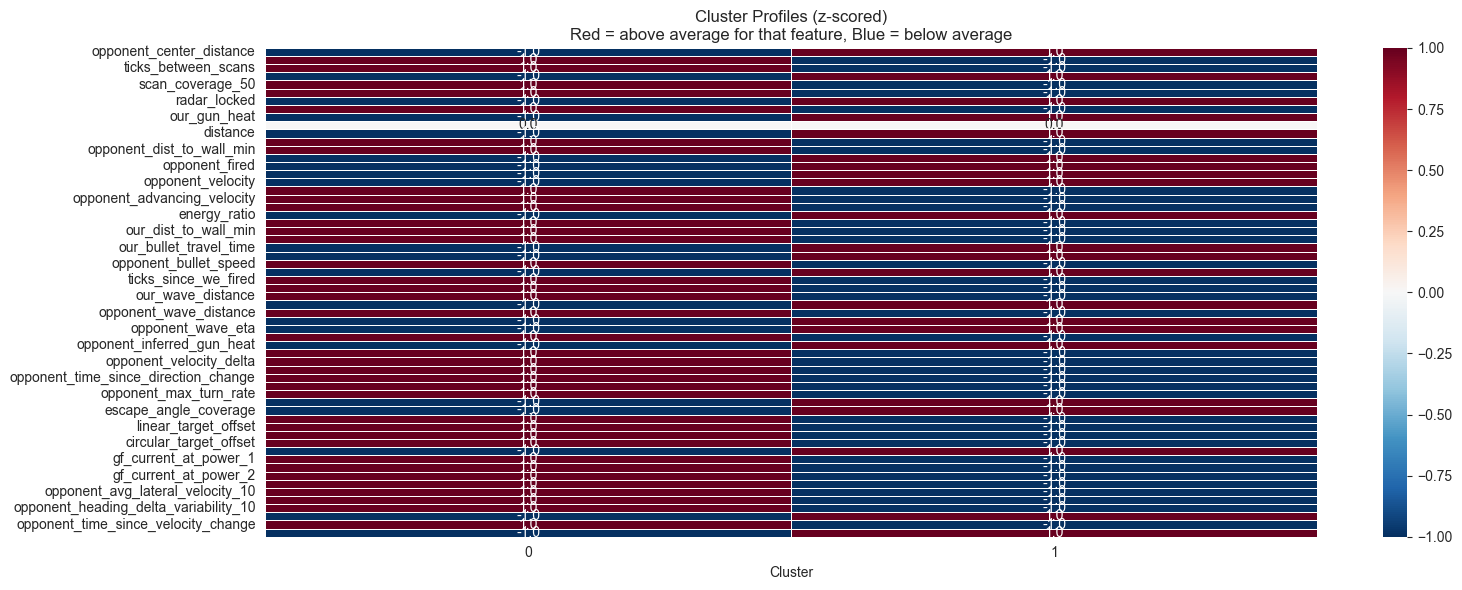

In [7]:
# --- Cluster profiles ---
features_with_cluster = features_df.copy()
features_with_cluster['cluster'] = cluster_labels

# Average feature values per cluster (using original scale, not z-scores)
profiles = features_with_cluster.groupby('cluster')[feature_cols].mean()
print("Cluster Profiles (average feature values):")
display(profiles.T.round(3))

# Heatmap of z-scored cluster centers (shows which features are above/below average)
scaler_profiles = StandardScaler()
profiles_z = pd.DataFrame(
    scaler_profiles.fit_transform(profiles),
    index=profiles.index,
    columns=profiles.columns
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(profiles_z.T, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5)
ax.set_title("Cluster Profiles (z-scored)\nRed = above average for that feature, Blue = below average")
ax.set_xlabel("Cluster")
plt.tight_layout()
plt.show()

## Step 5 — DBSCAN: Finding Irregularly Shaped Clusters

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) is different from K-Means:
- You don't pick K upfront — DBSCAN finds the number of clusters automatically
- It can find clusters of any shape (not just round blobs)
- It labels isolated points as **noise** (cluster = −1), meaning "this point doesn't belong to any group"

**Parameters:**
- `eps` = maximum distance between two points to be considered "neighbors"
- `min_samples` = minimum number of neighbors to form a dense region

DBSCAN is useful for finding unusual game states (outliers marked as noise).

DBSCAN found 0 clusters and 20000 noise points (100.0%)


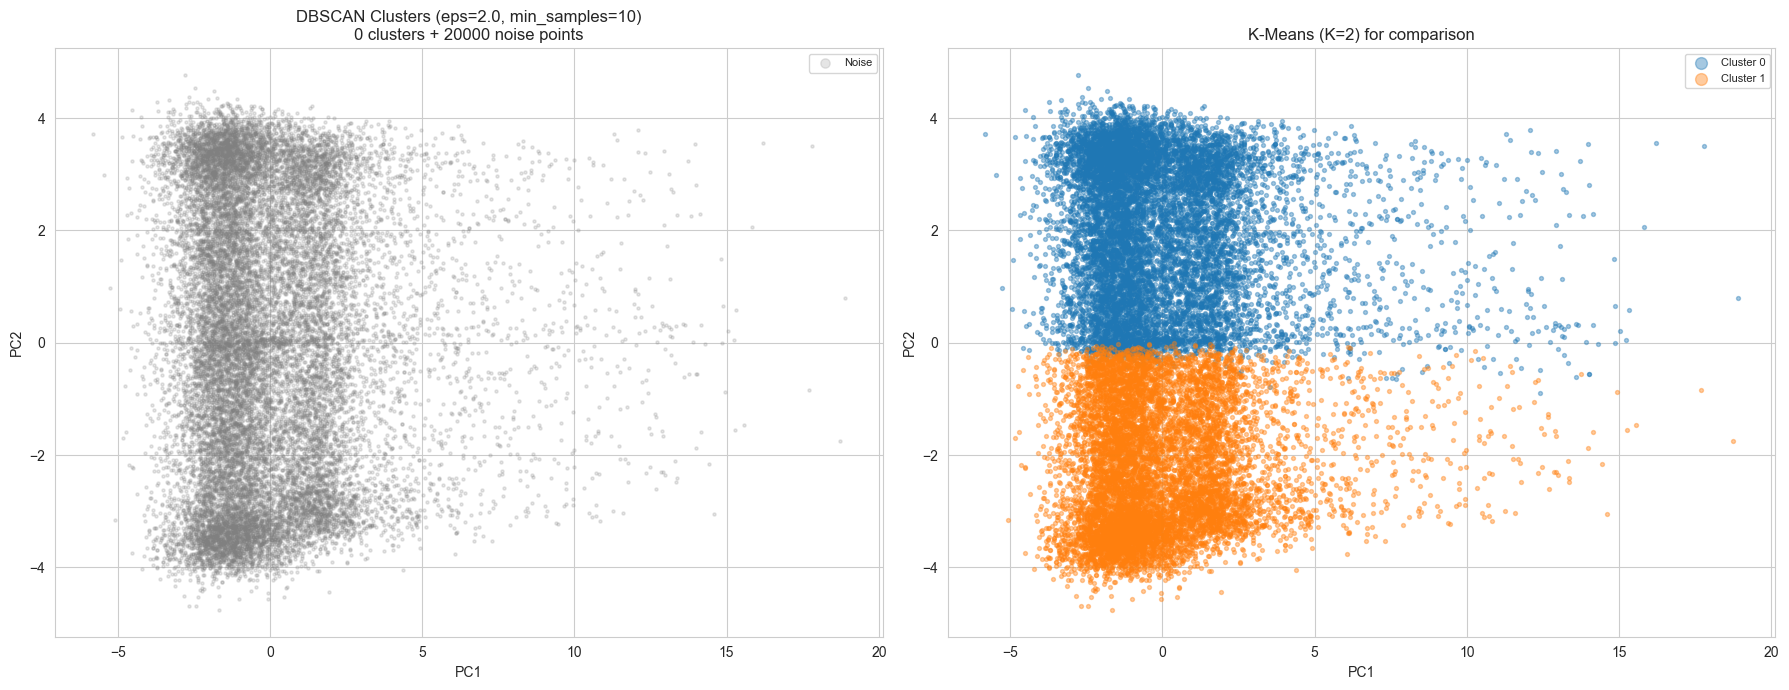

In [8]:
# --- DBSCAN (on a sample — DBSCAN is O(n²) on dense data) ---
X_dbscan = X_scaled[sample_idx_km]  # Reuse the same 20K sample

db = DBSCAN(eps=2.0, min_samples=10)
db_labels = db.fit_predict(X_dbscan)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"DBSCAN found {n_clusters_db} clusters and {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)")

# Visualize on PCA
X_pca_dbscan = pca_2d.transform(X_dbscan)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# DBSCAN clusters
noise_mask = db_labels == -1
axes[0].scatter(X_pca_dbscan[noise_mask, 0], X_pca_dbscan[noise_mask, 1],
                c='gray', alpha=0.2, s=5, label='Noise')
for c in range(n_clusters_db):
    mask = db_labels == c
    axes[0].scatter(X_pca_dbscan[mask, 0], X_pca_dbscan[mask, 1],
                    label=f'Cluster {c}', alpha=0.5, s=8)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title(f"DBSCAN Clusters (eps=2.0, min_samples=10)\n{n_clusters_db} clusters + {n_noise} noise points")
axes[0].legend(markerscale=3, fontsize=8)

# Compare: K-Means for same sample
km_sample_labels = km_best.predict(X_dbscan)
for c in range(best_k):
    mask = km_sample_labels == c
    axes[1].scatter(X_pca_dbscan[mask, 0], X_pca_dbscan[mask, 1],
                    label=f'Cluster {c}', alpha=0.4, s=8)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title(f"K-Means (K={best_k}) for comparison")
axes[1].legend(markerscale=3, fontsize=8)

plt.tight_layout()
plt.show()

## Step 6 — Waves Clustering

Let's also cluster the wave data (bullets fired). Do different bullet patterns naturally group together?

In [9]:
# --- Waves clustering ---
wave_meta = ['battle_id', 'round', 'tick', 'robot_name']
wave_features = [c for c in waves.columns if c not in wave_meta and waves[c].dtype in ['float64', 'int64']]

waves_clean = waves[wave_features].dropna()
wave_robots = waves.loc[waves_clean.index, 'robot_name']

if len(waves_clean) > 0 and len(wave_features) >= 2:
    # Scale and PCA
    wave_scaler = StandardScaler()
    W_scaled = wave_scaler.fit_transform(waves_clean)
    
    wave_pca = PCA(n_components=2)
    W_pca = wave_pca.fit_transform(W_scaled)
    
    # K-Means on waves
    wave_km = KMeans(n_clusters=3, random_state=42, n_init=10)
    wave_labels = wave_km.fit_predict(W_scaled)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Colored by robot
    for robot in sorted(wave_robots.unique()):
        mask = wave_robots.values == robot
        axes[0].scatter(W_pca[mask, 0], W_pca[mask, 1], label=robot, alpha=0.5, s=15)
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].set_title("Waves PCA — Colored by Robot")
    axes[0].legend(fontsize=8)
    
    # Colored by cluster
    for c in range(3):
        mask = wave_labels == c
        axes[1].scatter(W_pca[mask, 0], W_pca[mask, 1], label=f'Cluster {c}', alpha=0.5, s=15)
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")
    axes[1].set_title("Waves PCA — K-Means Clusters (K=3)")
    axes[1].legend(fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Wave cluster profiles
    waves_clean_with_labels = waves_clean.copy()
    waves_clean_with_labels['cluster'] = wave_labels
    print("\nWave cluster profiles:")
    display(waves_clean_with_labels.groupby('cluster').mean().round(3))
else:
    print(f"Not enough wave data for clustering ({len(waves_clean)} rows, {len(wave_features)} features)")

Not enough wave data for clustering (281447 rows, 0 features)
